<a href="https://colab.research.google.com/github/ramirosadlovsky20-code/ProcesamientoDelHabla/blob/main/Perez_Ramiro_PH_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**[Escriba aquí su nombre completo.]**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [ ]:
import requests
from bs4 import BeautifulSoup

In [ ]:
# declaro la url que voy a utilizar
url_discurso = 'https://deganadores.com/gerencia-y-gestion/discursos/inspirador-discurso-de-mark-zuckerberg-en-ceremonia-de-graduacion-en-harvard'

#obtengo el discurso
resp = requests.get(url_discurso)

In [ ]:
sopa = BeautifulSoup(resp.text, 'html.parser')

In [ ]:
# obtengo solo el contenido del discurso
contenido_discurso = sopa.find('div', class_='article-content-main')

#filtro o obtengo solo lo parrafos
elemento_parrafo = contenido_discurso.find_all('p')

In [ ]:
#creo una lista con todos los parrafos obtenidos y ademas lo convierto a minuscula
lista_parrafos = []
for elemento in elemento_parrafo:
  lista_parrafos.append(elemento.get_text().lower())

In [ ]:
# muestro toda mi lista de parrafos que obtuve
for element in lista_parrafos[:10]:
  print(element)

rectora faust, junta de supervisión, profesores, exalumnos, amigos, padres orgullosos, miembros de la junta asesora y graduados de la mejor universidad del mundo.
para mí es un honor estar hoy aquí, porque, digámoslo, habéis conseguido algo que yo nunca pude. si sobrevivo a este discurso, será la primera vez que termine algo en harvard. ¡enhorabuena, promoción del 2017!
se me hace raro estar aquí, no solo porque dejara la universidad, sino también porque, técnicamente, somos de la misma generación. hace menos de una década, yo estudiaba las mismas ideas y me quedaba dormido en las mismas clases. puede que hayamos tomado distintos caminos para llegar aquí, especialmente si venís desde el quad, pero hoy quiero hablar de lo que he aprendido de nuestra generación y del mundo en que vivimos.
estos dos últimos días me han traído muy buenos recuerdos.
¿cuántos recordáis qué estabais haciendo cuando recibisteis el email de admisión en harvard? yo estaba jugando al civilization. bajé corriendo 

In [ ]:
# Juntamos los parrafos para tener un texto completo
texto_completo= " ".join(lista_parrafos).replace('\n','')
print(texto_completo)

rectora faust, junta de supervisión, profesores, exalumnos, amigos, padres orgullosos, miembros de la junta asesora y graduados de la mejor universidad del mundo. para mí es un honor estar hoy aquí, porque, digámoslo, habéis conseguido algo que yo nunca pude. si sobrevivo a este discurso, será la primera vez que termine algo en harvard. ¡enhorabuena, promoción del 2017! se me hace raro estar aquí, no solo porque dejara la universidad, sino también porque, técnicamente, somos de la misma generación. hace menos de una década, yo estudiaba las mismas ideas y me quedaba dormido en las mismas clases. puede que hayamos tomado distintos caminos para llegar aquí, especialmente si venís desde el quad, pero hoy quiero hablar de lo que he aprendido de nuestra generación y del mundo en que vivimos. estos dos últimos días me han traído muy buenos recuerdos. ¿cuántos recordáis qué estabais haciendo cuando recibisteis el email de admisión en harvard? yo estaba jugando al civilization. bajé corriendo 

## 2- Preprocesamiento

In [ ]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 38.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

# cargo el modelo de lenguaje espanol
nlp = spacy.load("es_core_news_sm")

documento = nlp(texto_completo)

### 2.1 Muestra las stop words que tenga tu texto.

In [ ]:
stopwords_texto = set()

for element in documento:
  if element.is_stop:
    stopwords_texto.add(element.text)

print(f'StopWords que se encontraron en el texto: \n {stopwords_texto}')

StopWords que se encontraron en el texto: 
 {'aquellos', 'queremos', 'mucho', 'un', 'hace', 'pasado', 'tras', 'nuestras', 'embargo', 'sé', 'tuvo', 'nada', 'desde', 'hay', 'últimos', 'aquí', 'su', 'siendo', 'después', 'otros', 'soy', 'aquello', 'ser', 'todo', 'tienen', 'haber', 'les', 'muchos', 'mal', 'nuestro', 'tan', 'cada', 'serán', 'contra', 'esto', 'quien', 'buenos', 'diferentes', 'esos', 'es', 'dan', 'tenía', 'ahora', 'bien', 'para', 'porque', 'demasiado', 'manera', 'sabemos', 'posible', 'solo', 'aunque', 'gran', 'cuenta', 'ver', 'demás', 'habrá', 'qué', 'conseguir', 'nadie', 'unos', 'nuevos', 'siempre', 'sobre', 'hecho', 'sino', 'saben', 'estamos', 'algunos', 'habla', 'haya', 'incluso', 'cuantas', 'nuevas', 'esa', 'ya', 'se', 'fui', 'sabe', 'toda', 'misma', 'algo', 'vosotros', 'él', 'hoy', 'han', 'bueno', 'final', 'mientras', 'primer', 'nuestros', 'tanto', 'sin', 'con', 'hasta', 'están', 'ellas', 'grande', 'eso', 'veces', 'vuestra', 'tengo', 'mayor', 'cuándo', 'parece', 'ha', 'sa

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

In [ ]:
# Creo una lista vacia para guardar las palabras limpias
palabras_limpias = []

for element in documento:

  # Elimino stopwords, signos de puntuacion y caracteres que no sean palabras
  if not element.is_stop and not element.is_punct and element.is_alpha:
    palabras_limpias.append(element.text)

  # vuelvo a juntar todas las palabras para obtener nuevamente el texto completo, limpio
texto_limpio = " ".join(palabras_limpias)
print(texto_limpio)

rectora faust junta supervisión profesores exalumnos amigos padres orgullosos miembros junta asesora graduados universidad mundo honor digámoslo habéis conseguido pude sobrevivo discurso termine harvard enhorabuena promoción raro dejara universidad técnicamente generación década estudiaba ideas quedaba dormido clases hayamos tomado distintos caminos llegar especialmente venís quad quiero hablar aprendido generación mundo vivimos traído recuerdos recordáis estabais recibisteis email admisión harvard jugando civilization bajé corriendo padre cuya reacción grabarme abría email vídeo triste juro entrar harvard orgullosos padres recordáis clase harvard fundamentos informática increíble harry lewis llegaba puse camiseta di llevaba revés etiqueta entendía hablaba tío kx jin pareció darle terminamos trabajando juntos problemas dirige importante departamento facebook promoción tratar gente recuerdo harvard priscilla acababa lanzar plan broma web facemash junta asesora quería verme mundo pensaba

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Agrego palabras que no quiero que esten en la nube de palabras
stopwords_es = set(STOPWORDS)
stopwords_es.update(['di',
                     'echar',
                     'realmente',
                     'boys',
                     'luna',
                     'fiesta',
                     'amigo',
                     'llegar',
                     'hablaros',
                     'fuerza',
                     'dije',
                     'nivel',
                     'local',
                     'centro',
                     'presa',
                     'antiguo',
                     'chaval',
                     'salir',
                     'basta',
                     'hubiese',
                     'sentido',
                     'alguien',
                     'harry',
                     'enfermedades',
                     'siga',
                     'preocuparos',
                     'marcha',
                     'sacar',
                     'raro',
                     'vivimos',
                     'medios',
                     'alcanzar',
                     'graduados',
                     'hombre',
                     'grupo',
                     'derecho',
                     'oportunidades',
                     'faust',
                     'especialmente',
                     'honor',
                     'gracias',
                     'iglesia',
                     'metas',
                     'vinieron',
                     'kayla',
                     'metas',
                     'planeta',
                     'tiempo',
                     'iniciativa',
                     'david',
                     'votar',
                     'ciudad',
                     'conozco',
                     'formamos',
                     'preocuparos',
                     'hablar',
                     'trabajad',
                     'conserje',
                     'estudiante',
                     'recuerdo',
                     'construir',
                     'juntos',
                     'elegir',
                     'niha',
                     'mano',
                     'relevantes',
                     'enhorabuena',
                     'priscilla',
                     'potencial',
                     'futuro',
                     'conectar',
                     'miembros',
                     'pagar',
                     'lugar',
                     'conscientes',
                     'suficiente',
                     'conectado',
                     'triste',
                     'exalumnos',
                     'hagamos',
                     'global',
                     'pensando',
                     'hora',
                     'necesitamos',
                     'seguir',
                     'gente',
                     'lucha'
                     'generaciones',
                     'dinero',
                     'emprendedor',
                     'hubiera',
                     'pensaba',
                     'quedaba',
                     'darle',
                     'acababa',
                     'cine',
                     'email',
                     'profesores',
                     'forma',
                     'suerte',
                     'generaciones',
                     'voluntarios',
                     'equipo',
                     'quad',
                     'corriendo',
                     'asumir',
                     'lanzar',
                     'distintos',
                     'grabarme',
                     'echarme',
                     'verme',
                     'caulquiera',
                     'probablemente',
                     'organizaron',
                     'seguramente',
                     'broma',
                     'actualidad',
                     'mejores',
                     'asesora',
                     'kx',
                     'tengamos',
                     'emprendedores',
                     'lewis',
                     'encontrar',
                     'cuya',
                     'motivaciones',
                     'avanzando',
                     'fundamentos',
                     'engendrado',
                     'graduar',
                     'echaron',
                     'puse',
                     'destino',
                     'cola',
                     'consiguiendo',
                     'jin',
                     'vio',
                     'llegaba',
                     'ofrecer',
                     'juro',
                     'par',
                     'hayamos',
                     'nasa',
                     'frases',
                     'cree',
                     'agnes',
                     'sentir',
                     'estancia',
                     'maletas',
                     'club',
                     'conocimos',
                     'john',
                     'conseguido',
                     'sobrevivio',
                     'civilization',
                     'decirse',
                     'belltower',
                     'discurso',
                     'charla',
                     'amistades',
                     'naciones',
                     'sobrevivo',
                     'caulquiera',
                     'deprimidas',
                     'despedidas',
                     'lugares',
                     'web',
                     'video',
                     'iban',
                     'charlado',
                     'obrero',
                     'departamento',
                     'intentan',
                     'pude',
                     'etiqueta',
                     'centros',
                     'plan',
                     'amiga',
                     'pensar'
                     'hablaba',
                     'antemano',
                     'presidente',
                     'menores',
                     'despedida',
                     'respuesta',
                     'llenar',
                     'reto',
                     'terminamos',
                     'llevaba',
                     'clara',
                     'sienten',
                     'motivado',
                     'manos',
                     'noche',
                     'daros',
                     'obvio',
                     'ayudarme',
                     'jugando',
                     'malas'
                     ])

**Nube de palabras**

In [ ]:
nube = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stopwords_es
).generate(texto_limpio)

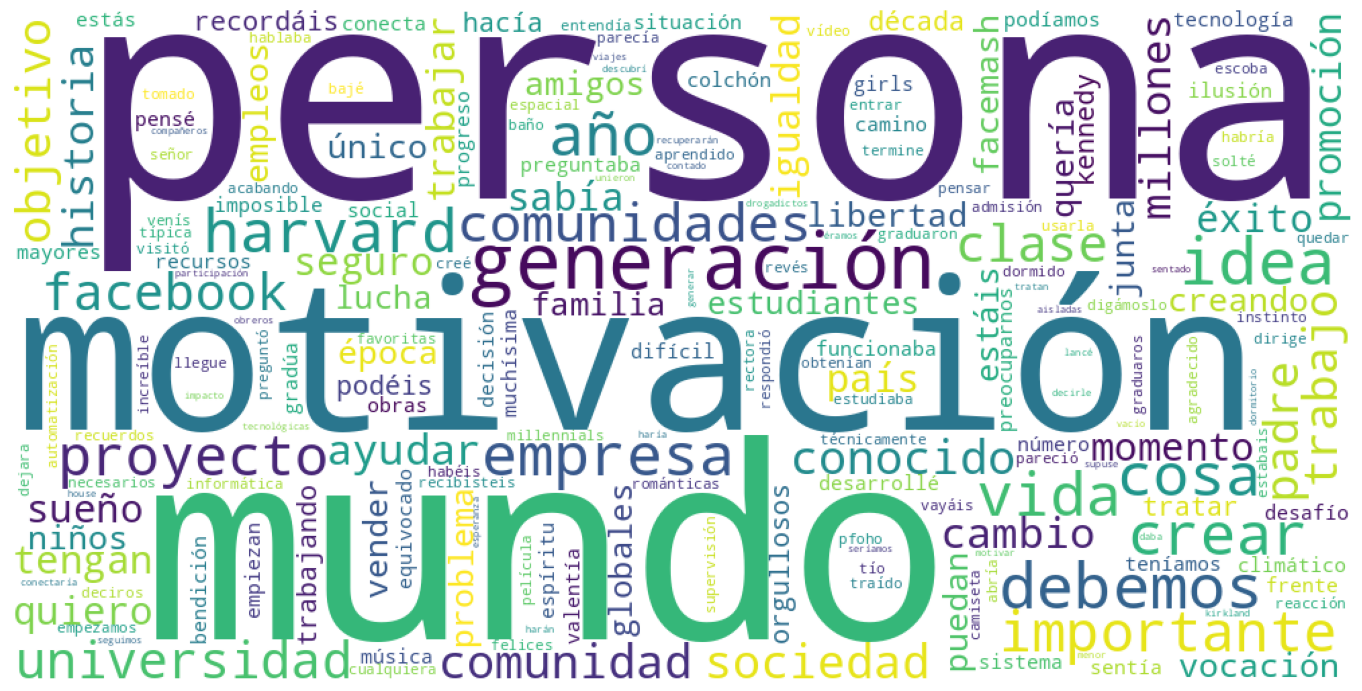

In [ ]:
plt.figure(figsize=(15,7))

plt.imshow(nube)
plt.tight_layout(pad=0)
plt.axis('off')
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [ ]:
oraciones_limpias = []

for oracion in documento.sents:
  palabras = []

  for elemento in oracion:
    # Elimino stopwords, signos de puntuacion y caracteres que no sean palabras
    if not elemento.is_stop and not elemento.is_punct and elemento.is_alpha:
      palabras.append(elemento.text)

  oraciones_limpias.append(" ".join(palabras))

In [ ]:
oraciones_7 = []
for i, oracion in enumerate(oraciones_limpias[:7]):
    print(f"Documento {i}: {oracion}")
    oraciones_7.append(oracion)

Documento 0: rectora faust junta supervisión profesores exalumnos amigos padres orgullosos miembros junta asesora graduados universidad mundo
Documento 1: honor digámoslo habéis conseguido pude
Documento 2: sobrevivo discurso termine harvard
Documento 3: enhorabuena promoción raro dejara universidad técnicamente generación
Documento 4: década estudiaba ideas quedaba dormido clases
Documento 5: hayamos tomado distintos caminos llegar especialmente venís quad quiero hablar aprendido generación mundo vivimos
Documento 6: traído recuerdos


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizador = CountVectorizer()
matriz_documento_vocabulario = vectorizador.fit_transform(oraciones_7)#(oraciones_limpias)#

print('Dimension de la matriz',matriz_documento_vocabulario.shape)
print(matriz_documento_vocabulario.toarray())

Dimension de la matriz (7, 49)
[[1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 2 0 1 1 1 1 1 0 0 0 0
  0 0 1 0 0 1 0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 1 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
  0 1 0 0 0 0 0 0 0 1 1 0 0]
 [0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1
  0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0
  1 0 0 0 0 0 0 1 0 0 0 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 1 0 0 0 0 1 0 0 0 0]]



#### 2.3.2 Determina la longitud de tu vocabulario.

In [ ]:
print('Longitud del vocabulario:',len(vectorizador.get_feature_names_out()))

Longitud del vocabulario: 49



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer
import pandas as pd

# Aplico TF-IDF a la matriz documento-vocabulario
tfidf_transformer = TfidfTransformer()

tfidf_transformer.fit(matriz_documento_vocabulario)

matriz_tfidf = tfidf_transformer.transform(matriz_documento_vocabulario)

# Muestro la matriz TF-IDF
df_tfidf = pd.DataFrame(matriz_tfidf.toarray(),columns= vectorizador.get_feature_names_out())

df_tfidf

,amigos,aprendido,asesora,caminos,clases,conseguido,dejara,digámoslo,discurso,distintos,...,recuerdos,sobrevivo,supervisión,termine,tomado,traído,técnicamente,universidad,venís,vivimos
0,0.247098,0.000000,0.247098,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.247098,0.0,0.000000,0.000000,0.000000,0.205112,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.447214,0.000000,0.447214,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.5,0.000000,...,0.000000,0.5,0.000000,0.5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.395963,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.395963,0.328683,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.408248,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.273403,0.000000,0.273403,0.000000,0.000000,0.000000,0.000000,0.0,0.273403,...,0.000000,0.0,0.000000,0.0,0.273403,0.000000,0.000000,0.000000,0.273403,0.273403
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.707107,0.0,0.000000,0.0,0.000000,0.707107,0.000000,0.000000,0.000000,0.000000


**Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.**


Como se puede obsrevar, la matriz que realice esta acortada para asi facilitar la visualizacion. Se puede ver que tenemos una cantidad total de 7 documentos  y una cantidad de 49 palabras/columnas que conforman el vocabulario. Cada valor de la matriz representa el peso TF-IDF de una palabra dentro del documento.  

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

El trabajo en si me gusto mucho, ya que se puede analizar tomando datos de una web y ver cuales son las palabras mas importantes y saber que esas palabras pueden brindar una informacion importante